# 01. Предобработка данных Paddy Dataset

**Цель:** подготовить данные о выращивании риса так, чтобы вся предобработка была **воспроизводимой**: один объект `Pipeline`, который принимает сырой CSV и выдаёт матрицу признаков.

**Целевая переменная:** `Paddy yield(in Kg)` — урожай риса с поля, кг.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from modules import plots
from modules.transformers import (
    TARGET, AREA_COL, NUMERIC_COLS, CATEGORICAL_ALL_COLS, CATEGORICAL_COLS,
    AGRO_INPUT_COLS, WEATHER_COLS, WATER_COLS, WIND_DIRECTION_COLS,
    make_column_cleaner, clean_column_names
)

RANDOM_STATE = 42
TEST_FRACTION = 0.20
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("models")
ARTIFACTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
plots.setup_style()
print(
    f"scikit-learn {sklearn_version}, pandas {pd.__version__}"
)

scikit-learn 1.9.1, pandas 3.0.6


## 1. Загрузка и аудит

Сначала ничего не исправляем, только смотрим: размер, типы, пропуски, число уникальных значений, дубликаты и т.д.

In [3]:
raw = pd.read_csv(DATA_DIR / "paddydataset.csv")

print(f"Размер: {raw.shape[0]} строк × {raw.shape[1]} колонок")
print(f"Пропусков всего: {int(raw.isnull().sum().sum())}")
print(f"Полных дубликатов: {raw.duplicated().sum()}")
print("Колонки с пробелами по краям:", [c for c in raw.columns if c != c.strip()])

audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isnull().sum(),
    "unique": raw.nunique(),
})
audit.T

Размер: 2789 строк × 45 колонок
Пропусков всего: 0
Полных дубликатов: 451
Колонки с пробелами по краям: ['Hectares ']


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,Pest_60Day(in ml),30DRain( in mm),30DAI(in mm),30_50DRain( in mm),30_50DAI(in mm),51_70DRain(in mm),51_70AI(in mm),71_105DRain(in mm),71_105DAI(in mm),Min temp_D1_D30,Max temp_D1_D30,Min temp_D31_D60,Max temp_D31_D60,Min temp_D61_D90,Max temp_D61_D90,Min temp_D91_D120,Max temp_D91_D120,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
dtype,int64,str,str,str,int64,float64,str,int64,int64,int64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,float64,float64,int64,int64,int64,int64,str,str,str,str,float64,int64,int64,int64,int64,int64
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
unique,6,6,3,2,6,6,2,6,6,6,6,6,6,6,6,3,3,3,3,3,3,3,3,6,5,6,5,6,6,5,5,4,4,3,3,6,5,5,6,6,6,5,6,17,477


**Что видно из аудита:**

* пропусков нет, но `SimpleImputer` всё равно ставим в пайплайн как защиту от будущих данных;
* почти все числовые признаки принимают **3–6 значений**: Так выглядят не измерения, а значения, подставленные из таблицы-справочника;
* **451 полный дубликат** (16 % строк).

## 2. Дубликаты: удаляем до разделения на train/test

Строка-дубликат совпадает по всем признакам **и по таргету**, поэтому её удаление не теряет информации. Важен порядок. Если сначала разделить, а потом чистить, копии одной строки окажутся и в train, и в test. Модель «узнает» тестовую строку, и метрика будет завышена. Проверим, насколько это реально:

In [4]:
# Что было бы, если бы мы сначала разделили сырые данные
leaky_test = raw.sample(frac=TEST_FRACTION, random_state=RANDOM_STATE)
leaky_train = raw.drop(index=leaky_test.index)
seen = leaky_test.merge(leaky_train.drop_duplicates(), how="inner").shape[0]
print(f"Тестовых строк, у которых есть точная копия в train: {seen} из {len(leaky_test)} "
      f"({seen / len(leaky_test):.0%})")

df = raw.drop_duplicates().reset_index(drop=True)
print(f"После удаления дубликатов: {len(df)} строк (удалено {len(raw) - len(df)})")

Тестовых строк, у которых есть точная копия в train: 150 из 558 (27%)
После удаления дубликатов: 2338 строк (удалено 451)


## 3. Отложенная тестовая выборка → `data/test.csv`

Отбираем 20 % случайных строк и сохраняем их **в исходном формате**.

In [5]:
test_df = df.sample(frac=TEST_FRACTION, random_state=RANDOM_STATE)
train_df = df.drop(index=test_df.index)

assert train_df.index.intersection(test_df.index).empty
test_df.to_csv(DATA_DIR / "test.csv", index=False)
train_df.to_csv(DATA_DIR / "train.csv", index=False)

print(
      f"train.csv: {len(train_df)} строк | test.csv: {len(test_df)} строк "
      f"({len(test_df) / len(df):.0%})"
)

train.csv: 1870 строк | test.csv: 468 строк (20%)


## 4. Разведочный анализ (только train)

Для графиков берём копию с очищенными именами колонок. Это то же действие, что делает первый шаг пайплайна.

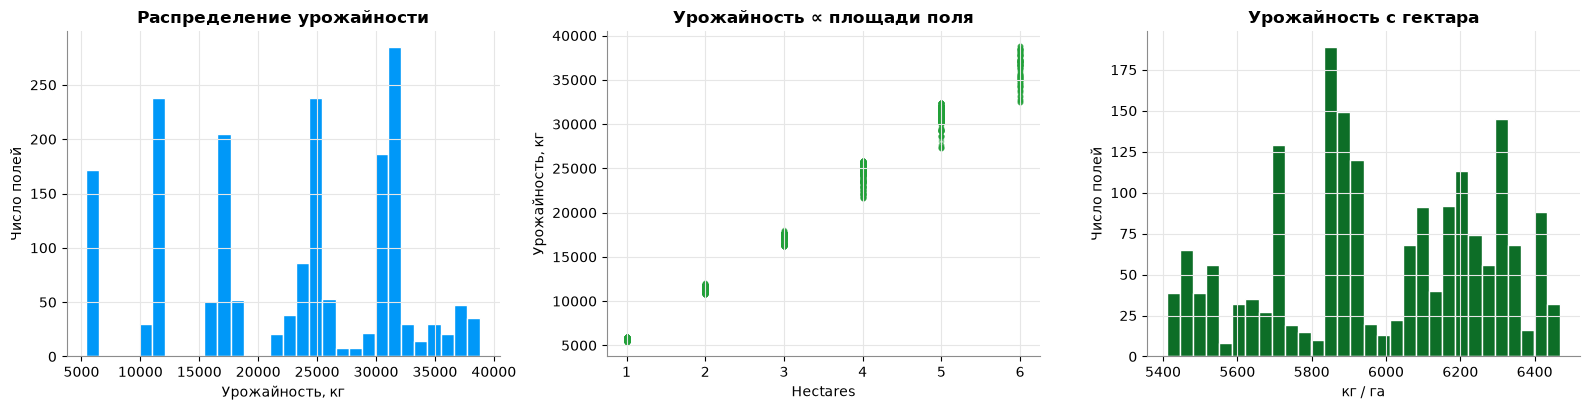

In [6]:
train_df.rename(columns=lambda c: str(c).strip(), inplace=True)
plots.plot_target_overview(train_df[TARGET], train_df[AREA_COL])

* Распределение урожая **многомодальное**: это не «шум», а шесть размеров полей (1–6 га).
* Урожай почти строго пропорционален площади (средний график). Значит, высокий R² достигается одной колонкой `Hectares`, и высокий R² у модели не будет признаком её качества.
* Урожайность **с гектара** лежит в узком коридоре ≈ 5 400–6 500 кг/га. Именно эту вариацию (±5 %) и предстоит объяснять.

Посмотрим, какие числовые признаки связаны с таргетом и как они соотносятся с площадью.

,corr_with_target,unique_values,unique_ratio_to_ha
Hectares,0.9945,6,1
Seedrate(in Kg),0.9945,6,1
LP_Mainfield(in Tonnes),0.9945,6,1
Nursery area (Cents),0.9945,6,1
LP_nurseryarea(in Tonnes),0.9945,6,1
DAP_20days,0.9945,6,1
Weed28D_thiobencarb,0.9945,6,1
Urea_40Days,0.9945,6,1
Potassh_50Days,0.9945,6,1
Micronutrients_70Days,0.9945,6,1


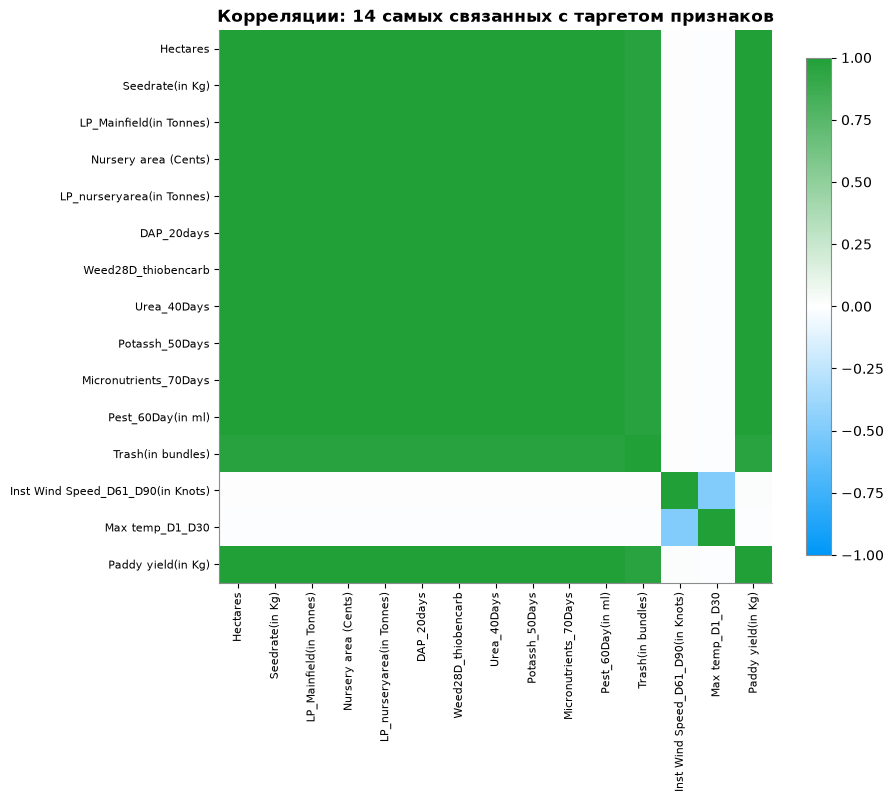

In [7]:
num = train_df[NUMERIC_COLS]
area_check = pd.DataFrame({
    "corr_with_target": num.corrwith(train_df[TARGET]).round(4),
    "unique_values": num.nunique(),
    "unique_ratio_to_ha": (num.div(train_df[AREA_COL], axis=0).round(2)).nunique(),
})
display(area_check.sort_values("corr_with_target", ascending=False).head(14))

top = area_check["corr_with_target"].abs().sort_values(ascending=False).index[:14].tolist()
plots.plot_corr_heatmap(
    train_df[top + [TARGET]].corr(), 
    title="Корреляции: 14 самых связанных с таргетом признаков"
)

**Находка:** у всех 10 агрономических колонок (семена, удобрения, гербицид и т. д.) корреляция с таргетом одинаковая — 0.9946, а отношение к `Hectares` принимает **одно** значение. Иначе говоря, это `Hectares × константа`: сплошной зелёный блок на тепловой карте — одна и та же информация, повторённая 11 раз. Погода и скорость ветра с таргетом почти не связаны.

In [8]:
# Сколько разных значений принимает погода / вода / ветер внутри одного агроблока?
within_block = train_df.groupby("Agriblock")[WEATHER_COLS + WATER_COLS + WIND_DIRECTION_COLS].nunique()
print("Максимум уникальных значений внутри одного Agriblock:", within_block.to_numpy().max())

Максимум уникальных значений внутри одного Agriblock: 1


**Вторая находка:** погода, водный режим и направления ветра **полностью определяются агроблоком**: внутри блока каждая из 28 колонок принимает одно значение. Эти колонки — тот же `Agriblock`, записанный другими словами.

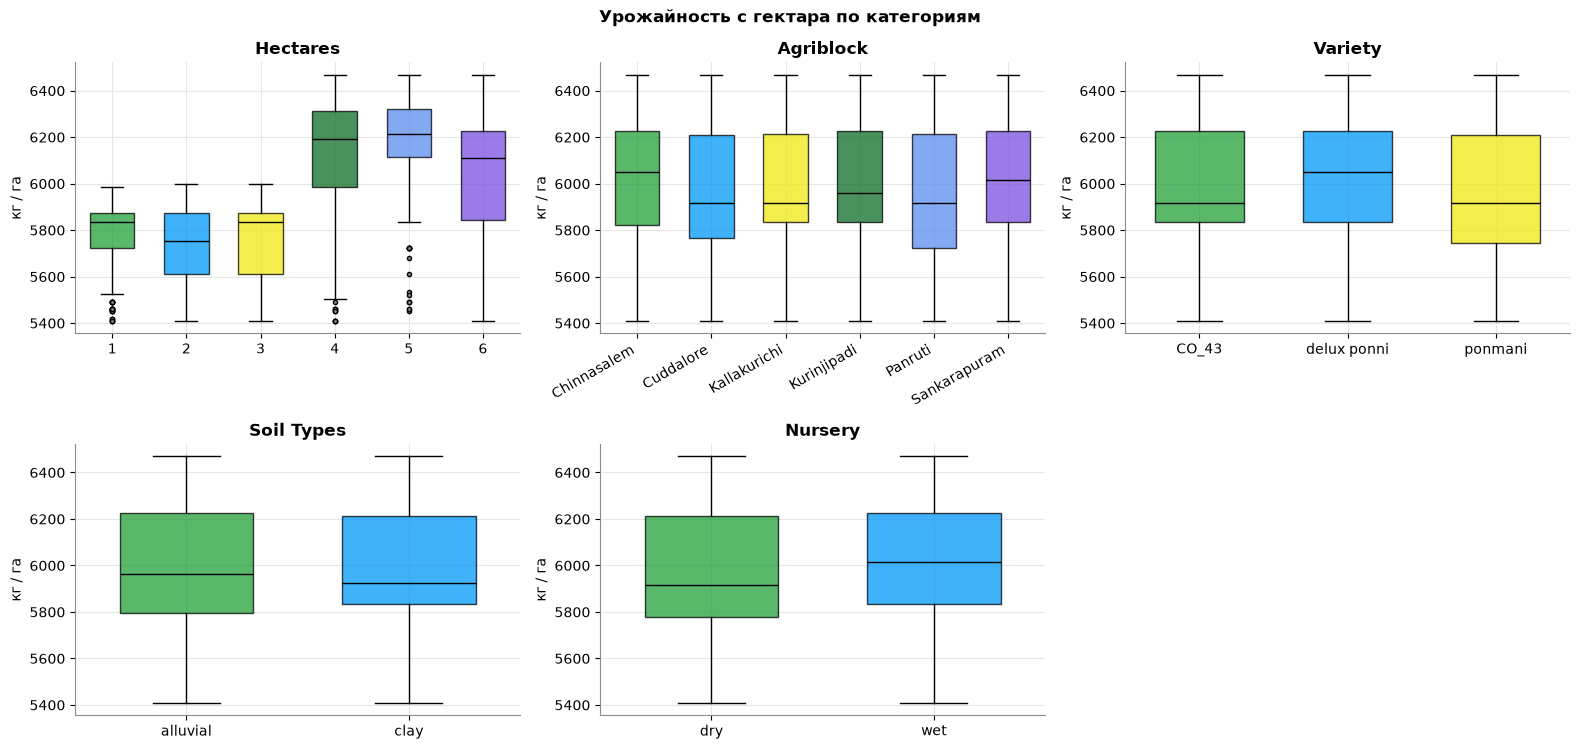

In [9]:
train_df["yield_per_ha"] = train_df[TARGET] / train_df[AREA_COL]
plots.plot_box_by(
    train_df, "yield_per_ha", [AREA_COL] + CATEGORICAL_COLS, ncols=3,
    ylabel="кг / га", title="Урожайность с гектара по категориям"
)

* Сильнее всего на урожайность с гектара влияет **сам размер поля**: 1–3 га ≈ 5 740 кг/га, 4–6 га заметно выше.
* Различия между сортами, блоками, типами почвы и питомника — в пределах десятков кг/га.

### Выбросы

Автоматически выбросы не удаляем. Все значения — из небольшого набора допустимых норм, а урожайность с гектара лежит в физически правдоподобном коридоре.

## 5. Базовый воспроизводимый пайплайн

```
сырой DataFrame
  └─ Pipeline
       ├─ clean : FunctionTransformer(clean_column_names)      без состояния
       └─ prep  : ColumnTransformer                             remainder="drop"
            ├─ num : SimpleImputer(median) → StandardScaler     36 числовых колонок
            └─ cat : SimpleImputer(most_frequent) → OneHotEncoder(handle_unknown="ignore")   8 категориальных колонок
```

In [10]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = Pipeline([
    ("clean", make_column_cleaner()),
    ("prep", ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, NUMERIC_COLS),
            ("cat", categorical_pipe, CATEGORICAL_ALL_COLS),
        ],
        remainder="drop",
    )),
]).set_output(transform="pandas")

In [11]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_train_prep = preprocessor.fit_transform(X_train)
print(f"{X_train.shape[1]} исходных колонок → {X_train_prep.shape[1]} признаков "
      f"(числовых {len(NUMERIC_COLS)}, one-hot {X_train_prep.shape[1] - len(NUMERIC_COLS)})")
show_cols = list(X_train_prep.columns[:3]) + [c for c in X_train_prep.columns if c.startswith("cat__")][:4]
X_train_prep[show_cols].head()

45 исходных колонок → 71 признаков (числовых 36, one-hot 35)


,num__Hectares,num__Seedrate(in Kg),num__LP_Mainfield(in Tonnes),cat__Agriblock_Chinnasalem,cat__Agriblock_Cuddalore,cat__Agriblock_Kallakurichi,cat__Agriblock_Kurinjipadi
0,1.567909,1.567909,1.567909,0.0,1.0,0.0,0.0
1,1.567909,1.567909,1.567909,0.0,0.0,0.0,1.0
2,1.567909,1.567909,1.567909,0.0,0.0,0.0,0.0
3,1.567909,1.567909,1.567909,0.0,0.0,1.0,0.0
4,1.567909,1.567909,1.567909,0.0,0.0,0.0,0.0


Каждый шаг хранит то, чему научился на train:

In [12]:
ct = preprocessor.named_steps["prep"]
num_imputer = ct.named_transformers_["num"].named_steps["imputer"]
scaler = ct.named_transformers_["num"].named_steps["scaler"]
onehot = ct.named_transformers_["cat"].named_steps["onehot"]

display(pd.DataFrame({
    "median (imputer)": num_imputer.statistics_[:4],
    "mean_ (scaler)": scaler.mean_[:4],
    "scale_ (scaler)": scaler.scale_[:4],
}, index=NUMERIC_COLS[:4]).round(2))
print("Категории Variety:", list(onehot.categories_[CATEGORICAL_ALL_COLS.index("Variety")]))

,median (imputer),mean_ (scaler),scale_ (scaler)
Hectares,4.0,3.72,1.45
Seedrate(in Kg),100.0,93.09,36.30
LP_Mainfield(in Tonnes),50.0,46.54,18.15
Nursery area (Cents),80.0,74.47,29.04


Категории Variety: ['CO_43', 'delux ponni', 'ponmani']


## 6. Проверка на «неудобных» новых данных

В проде может прийти строка с пропуском и с категорией, которой не было в train. Пайплайн не должен падать:

* пропуск в числовой колонке заменяется **медианой train**;
* неизвестный сорт превращается в нули во всём блоке `Variety_*`.

In [13]:
new_rows = X_train.head(2).copy()
new_rows.loc[new_rows.index[0], "Hectares"] = np.nan        # пропуск
new_rows.loc[new_rows.index[1], "Variety"] = "IR_64"         # новый сорт

out = preprocessor.transform(new_rows)
print("NaN на выходе:", int(out.isna().sum().sum()))
variety_cols = [c for c in out.columns if "Variety" in c]
out[["num__Hectares"] + variety_cols]

NaN на выходе: 0


,num__Hectares,cat__Variety_CO_43,cat__Variety_delux ponni,cat__Variety_ponmani
0,0.190418,1.0,0.0,0.0
1,1.567909,0.0,0.0,0.0


## 7. Проверка воспроизводимости

Свежий клон пайплайна, обученный на тех же данных, **даже в другом порядке строк**, обязан дать тот же результат.

In [14]:
shuffled = X_train.sample(frac=1, random_state=7)
X_again = clone(preprocessor).fit(shuffled).transform(X_train)

print("Та же форма:", X_again.shape == X_train_prep.shape)
print("Те же имена признаков:", list(X_again.columns) == list(X_train_prep.columns))
print("Те же значения:", np.allclose(X_again.to_numpy(), X_train_prep.to_numpy()))

Та же форма: True
Те же имена признаков: True
Те же значения: True


## 8. Сохранение

* `data/train.csv`, `data/test.csv` — сохранены в разделе 3;
* `models/preprocessor_base.joblib` — базовый пайплайн, обученный на train.

In [15]:
joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor_base.joblib")

['models/preprocessor_base.joblib']